In [1]:
import pickle
from representation_analysis import compute_rate_maps_single
from plotting import plot_units_rate_maps
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from ratinabox.Environment import Environment
from ratinabox.Agent import Agent
from viz import display_reward_patch
import numpy as np
from representation_analysis import compute_dead_neurons


In [2]:
relu_data_out = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/ReLU/env_empty/seed_0/all_out_arrays_seed_0", "rb"))
relu_data_bins = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/ReLU/env_empty/seed_0/all_episodes_bins_seed_0", "rb"))
relu_data_states = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/ReLU/env_empty/seed_0/all_episodes_states_seed_0", "rb"))
fta_data_out = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_empty/seed_0/all_out_arrays_seed_0", "rb"))
fta_data_bins = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_empty/seed_0/all_episodes_bins_seed_0", "rb"))
fta_data_states = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_empty/seed_0/all_episodes_states_seed_0", "rb"))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mariedelvalle/Documents/projects/RatInABox/data/ReLU/env_empty/seed_0/all_episodes_bins_seed_0'

In [ ]:
OBSTACLES = {
    "empty": [],

    "obstacle_near_goal": [
        {"x_min": 0.30, "x_max": 0.45, "y_min": 0.30, "y_max": 0.45}
    ],

    "obstacle_corners": [
        # bottom-left
        {"x_min": 0.0,  "x_max": 0.15, "y_min": 0.0,  "y_max": 0.15},

        # bottom-right
        {"x_min": 0.85, "x_max": 1.0,  "y_min": 0.0,  "y_max": 0.15},

        # top-left
        {"x_min": 0.0,  "x_max": 0.15, "y_min": 0.85, "y_max": 1.0},

        # top-right
        {"x_min": 0.85, "x_max": 1.0,  "y_min": 0.85, "y_max": 1.0},
    ],
}
fta_data_states_corners = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_obstacle_corners/seed_0/all_episodes_states_seed_0", "rb"))
fta_data_out_corners = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_obstacle_corners/seed_0/all_out_arrays_seed_0", "rb"))

In [ ]:
fta_data_states_corners[1]

[array([0.93157322, 0.3396419 ]),
 array([0.9359161 , 0.33581929]),
 array([0.94022139, 0.32833932]),
 array([0.94778898, 0.32543877]),
 array([0.95264361, 0.32020312]),
 array([0.95576411, 0.316072  ]),
 array([0.96064371, 0.31459335]),
 array([0.96128447, 0.31181481]),
 array([0.96139866, 0.31037081]),
 array([0.96274266, 0.30860971]),
 array([0.96422119, 0.30824954]),
 array([0.96886902, 0.31025895]),
 array([0.97130939, 0.31173122]),
 array([0.97130814, 0.3072568 ]),
 array([0.96927867, 0.3043117 ]),
 array([0.96682166, 0.30126849]),
 array([0.96458978, 0.29591966]),
 array([0.96058141, 0.29455424]),
 array([0.95585532, 0.29400736]),
 array([0.95192857, 0.29551711]),
 array([0.94554631, 0.29746161]),
 array([0.94259517, 0.29898657]),
 array([0.935098  , 0.30032225]),
 array([0.9270426 , 0.30256292]),
 array([0.92278212, 0.30670054]),
 array([0.91633423, 0.31111178]),
 array([0.91322209, 0.31336196]),
 array([0.90935469, 0.31526274]),
 array([0.90652493, 0.31915351]),
 array([0.9019

In [ ]:
def is_in_obstacle(x, y, obstacles):
    for obs in obstacles:
        if (obs["x_min"] <= x <= obs["x_max"] and
            obs["y_min"] <= y <= obs["y_max"]):
            return True
    return False

def check_activation_in_obstacles(states, out_arrays, obstacles, threshold=0.0):
    """
    Check whether any activations occur inside obstacle regions.

    Returns:
        total_points_in_obstacles
        total_active_points_in_obstacles
    """

    total_points = 0
    active_points = 0

    for ep_states, ep_outs in zip(states, out_arrays):
        for (x, y), out in zip(ep_states, ep_outs):

            if is_in_obstacle(x, y, obstacles):
                total_points += 1

                # Check if ANY unit is active
                if np.any(np.array(out) > threshold):
                    active_points += 1

    return total_points, active_points

In [ ]:
obstacles = OBSTACLES['obstacle_corners']

total, active = check_activation_in_obstacles(
    fta_data_states_corners,
    fta_data_out_corners,
    obstacles,
    threshold=0.1
)

print(f"Points inside obstacles: {total}")
print(f"Active points inside obstacles: {active}")

Points inside obstacles: 0
Active points inside obstacles: 0


(<Figure size 250x250 with 1 Axes>, <Axes: >)

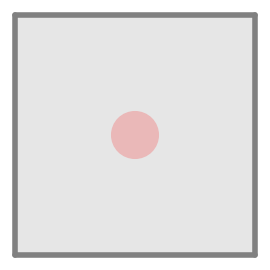

In [ ]:
env = Environment()
resolution = 0.01  # spacing between walls
    
fig, ax =env.plot_environment()
display_reward_patch(fig, ax, reward_location=[0.5, 0.5], reward_radius=0.1)


(<Figure size 250x250 with 1 Axes>, <Axes: >)

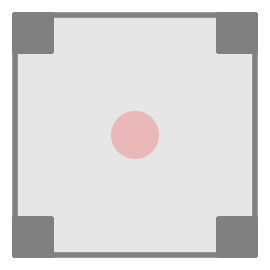

In [ ]:
def get_environment(env, shape="empty"):
    """
    Adds obstacles to the environment based on OBSTACLES dict.
    Each obstacle is defined by x_min, x_max, y_min, y_max.
    """

    obstacles = OBSTACLES.get(shape, [])

    resolution = 0.01  # spacing for filling obstacles

    for obs in obstacles:
        x_min, x_max = obs["x_min"], obs["x_max"]
        y_min, y_max = obs["y_min"], obs["y_max"]

        # ---- outer walls (rectangle boundary) ----
        env.add_wall([[x_min, y_min], [x_min, y_max]])  # left
        env.add_wall([[x_min, y_max], [x_max, y_max]])  # top
        env.add_wall([[x_max, y_max], [x_max, y_min]])  # right
        env.add_wall([[x_max, y_min], [x_min, y_min]])  # bottom

        # ---- fill interior with horizontal lines ----
        for y in np.arange(y_min, y_max, resolution):
            env.add_wall([[x_min, y], [x_max, y]])

    return env

OBSTACLES = {
    "empty": [],

    "obstacle_near_goal": [
        {"x_min": 0.30, "x_max": 0.45, "y_min": 0.30, "y_max": 0.45}
    ],

    "obstacle_corners": [
        # bottom-left
        {"x_min": 0.0,  "x_max": 0.15, "y_min": 0.0,  "y_max": 0.15},

        # bottom-right
        {"x_min": 0.85, "x_max": 1.0,  "y_min": 0.0,  "y_max": 0.15},

        # top-left
        {"x_min": 0.0,  "x_max": 0.15, "y_min": 0.85, "y_max": 1.0},

        # top-right
        {"x_min": 0.85, "x_max": 1.0,  "y_min": 0.85, "y_max": 1.0},
    ],

    # NEW: walls
    "walls": [
        # vertical wall: x = 0.40 from y = 0 → 0.60
        {"x_min": 0.40, "x_max": 0.40, "y_min": 0.0,  "y_max": 0.60},

        # horizontal wall: y = 0.60 from x = 0.40 → 0.80
        {"x_min": 0.40, "x_max": 0.80, "y_min": 0.60, "y_max": 0.60},
    ]
}

fig, ax =env.plot_environment()
display_reward_patch(fig, ax, reward_location=[0.5, 0.5], reward_radius=0.1)


In [ ]:
# Mock data: 3 runs, 5 episodes each, 10 timesteps, 20 FTA units
np.random.seed(0)

runs_out_arrays = []
for run in range(3):
    run_data = []
    for ep in range(5):
        # Each episode: 10 timesteps, 20 units
        # Make some units always dead (< 0.1) to test
        ep_data = []
        for t in range(10):
            output = np.random.uniform(0, 1, size=20)
            output[:5] = 0.0  # first 5 units always dead
            ep_data.append(output)
        run_data.append(ep_data)
    runs_out_arrays.append(run_data)

# Test
means, lows, highs = compute_dead_neurons(runs_out_arrays, thres=0.1)

print(f"Shape of means: {means.shape}")  # should be (5,) one per episode
print(f"Means: {means}")                 # should be ~25% (5 out of 20 units dead)
print(f"CI low: {lows}")
print(f"CI high: {highs}")